# Extensions of the project

We want in this notebook simulate the extensions presented in other articles we read about. Namely here:
- The "Late Rewinding" (Reset to Epoch k)
- and the "Strong Lottery Ticket Hypothesis" (Pruning without Training)

The below cell help load or download the librairies if you don't have it already (convenient when using datalab)

In [1]:
import sys
import os
import subprocess

print("Initialisation de l'environnement...")


def install_package(package):
    print(f"Téléchargement de '{package}' en cours...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import torchvision
    import torch
    import pandas as pd
    import time
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import seaborn as sns
    print("Toutes les librairies externes sont déjà présentes.")

except ImportError as e:
    print(f"Il manque des librairies (Erreur: {e}). Installation en cours...")
    pkgs = ["pandas", "matplotlib", "seaborn", "tqdm", "torch", "torchvision"]
    for pkg in pkgs:
        try:
            __import__(pkg) 
        except ImportError:
            install_package(pkg)
            
    import torchvision
    import torch
    import pandas as pd
    import time
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import seaborn as sns
    print("Installation terminée et librairies chargées.")


# loading local files
try:
    from Neural_networks import *
    from Comparing_results import *
    from Extension_analysis_functions import *
    print("Tes fichiers locaux (Neural_networks, Comparing_results, Extension_analysis_functions) sont bien chargés.")

except ImportError as e:
    print("\n" + "_"*60)
    print(f"ERREUR : Impossible de trouver le fichier '{e.name}'.")
    print("SOLUTION : Tu dois 'Uploader' (Glisser-Déposer) tes fichiers .py")
    print("(Neural_networks.py, Comparing_results.py, Extension_analysis_functions.py)")
    print("dans la barre de gauche de VS Code ou Jupyter.")
    print("_"*60 + "\n")


# check torch GPU availability (without it's impossible to run the code in short time)
if torch.cuda.is_available():
    print(f"\nEXCELLENT : GPU détecté -> {torch.cuda.get_device_name(0)}")
else:
    print("\nATTENTION : Aucun GPU détecté. L'entraînement sera lent (CPU).")

Initialisation de l'environnement...
Il manque des librairies (Erreur: No module named 'torchvision'). Installation en cours...
Téléchargement de 'torch' en cours...
  Using cached torch-2.9.1-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cublas_cu12-12.8

## Extension: "Late Rewinding" (Reset to Epoch k)

This extension is applied when standard Lottery Ticket Hypothesis experiments fail to identify winning tickets, typically on complex datasets like CIFAR-10 or with deeper network architectures. Resetting weights strictly to initialization (Epoch 0) can be unstable because the optimization trajectory is highly sensitive to stochastic noise during the very first iterations. Late Rewinding addresses this by resetting the pruned network's weights to their state after a small number of warmup epochs (e.g., Epoch 2) instead of the initial state. By this point, the network has entered a stable optimization basin, allowing the sparse subnetwork to train successfully without diverging. Consequently, this method maintains high accuracy at extreme sparsity levels where the standard initialization approach often collapses.

In [2]:
#parameters
TOTAL_PRUNE_PERCENT = 90
ROUNDS = 5
EPOCHS = 5
REPEATS = 3
REWIND_EPOCH = 2 
safe_lr=0.01



# Method 1 : Standard LTH (Reset to epoch 0)
def method_standard_lth():
    return iterative_pruning_CIFAR(
        total_prune_percent=TOTAL_PRUNE_PERCENT,
        rounds=ROUNDS,
        epochs_per_round=EPOCHS,
        lr=0.01,
        LTH=True,
        optimizer_type="sgd"
    )

# Method 2 : Late Rewinding (Reset to epoch 2)
def method_late_rewinding():
    return iterative_pruning_CIFAR_Rewinding(
        total_prune_percent=TOTAL_PRUNE_PERCENT,
        rounds=ROUNDS,
        epochs_per_round=EPOCHS,
        rewind_epoch=REWIND_EPOCH, # <-- Le changement clé
        lr=0.01,
        optimizer_type="sgd"
    )

print(" Lancement de la comparaison : Standard vs Late Rewinding sur CIFAR-10...")

df_std, df_rewind = comparing_methods_initialization_after_pruning(
    amount_of_repeats=REPEATS,
    rounds=ROUNDS,
    method_1=method_standard_lth,
    method_2=method_late_rewinding
)

 Lancement de la comparaison : Standard vs Late Rewinding sur CIFAR-10...


Repeats:   0%|          | 0/3 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for CIFAR.
   -> Optimizer used: SGD (momentum=0.9)
Initial accuracy : 55.86%.

Creating the Winning ticket
At each round, we are pruning : 36.90% of the weights.

--- Round 1/5 ---
Current pruning percentage: 36.88%
Accuracy after retraining: 67.01%

--- Round 2/5 ---
Current pruning percentage: 60.15%
Accuracy after retraining: 69.18%

--- Round 3/5 ---
Current pruning percentage: 74.83%
Accuracy after retraining: 76.15%

--- Round 4/5 ---
Current pruning percentage: 84.09%
Accuracy after retraining: 76.35%

--- Round 5/5 ---
Current pruning percentage: 89.93%
Accuracy after retraining: 73.78%

Step 1: Training Dense Network with Rewinding capture at Epoch 2...
   -> Warming up for 2 epochs...
   -> Theta_2 saved! (Checkpoint created)
Initial dense accuracy : 68.17%. Loss: 0.8954

Step 4: Creating the Winning ticket (Reset to Epoch 2)

--- Round 1/5 ---
Accuracy: 81.20%. Loss: 0.5450

--- Round 2/5 ---
Accuracy: 81.70%. 

Repeats:  33%|███▎      | 1/3 [28:43<57:27, 1723.77s/it]

Accuracy: 84.10%. Loss: 0.4296

Step 1 and 2: training the randomly initialized neural network for CIFAR.
   -> Optimizer used: SGD (momentum=0.9)
Initial accuracy : 57.86%.

Creating the Winning ticket
At each round, we are pruning : 36.90% of the weights.

--- Round 1/5 ---
Current pruning percentage: 36.88%
Accuracy after retraining: 66.72%

--- Round 2/5 ---
Current pruning percentage: 60.15%
Accuracy after retraining: 74.18%

--- Round 3/5 ---
Current pruning percentage: 74.83%
Accuracy after retraining: 77.32%

--- Round 4/5 ---
Current pruning percentage: 84.09%
Accuracy after retraining: 77.51%

--- Round 5/5 ---
Current pruning percentage: 89.93%
Accuracy after retraining: 76.65%

Step 1: Training Dense Network with Rewinding capture at Epoch 2...
   -> Warming up for 2 epochs...
   -> Theta_2 saved! (Checkpoint created)
Initial dense accuracy : 67.92%. Loss: 0.8931

Step 4: Creating the Winning ticket (Reset to Epoch 2)

--- Round 1/5 ---
Accuracy: 79.59%. Loss: 0.5789

--- R

Repeats:  67%|██████▋   | 2/3 [57:26<28:43, 1723.29s/it]

Accuracy: 83.20%. Loss: 0.4494

Step 1 and 2: training the randomly initialized neural network for CIFAR.
   -> Optimizer used: SGD (momentum=0.9)
Initial accuracy : 58.34%.

Creating the Winning ticket
At each round, we are pruning : 36.90% of the weights.

--- Round 1/5 ---
Current pruning percentage: 36.88%
Accuracy after retraining: 69.11%

--- Round 2/5 ---
Current pruning percentage: 60.15%
Accuracy after retraining: 74.47%

--- Round 3/5 ---
Current pruning percentage: 74.83%
Accuracy after retraining: 77.39%

--- Round 4/5 ---
Current pruning percentage: 84.09%
Accuracy after retraining: 77.16%

--- Round 5/5 ---
Current pruning percentage: 89.93%
Accuracy after retraining: 76.04%

Step 1: Training Dense Network with Rewinding capture at Epoch 2...
   -> Warming up for 2 epochs...
   -> Theta_2 saved! (Checkpoint created)
Initial dense accuracy : 69.32%. Loss: 0.8739

Step 4: Creating the Winning ticket (Reset to Epoch 2)

--- Round 1/5 ---
Accuracy: 79.49%. Loss: 0.5899

--- R

Repeats: 100%|██████████| 3/3 [1:26:02<00:00, 1720.90s/it]

Accuracy: 83.71%. Loss: 0.4414
Total time: 86.05 minutes


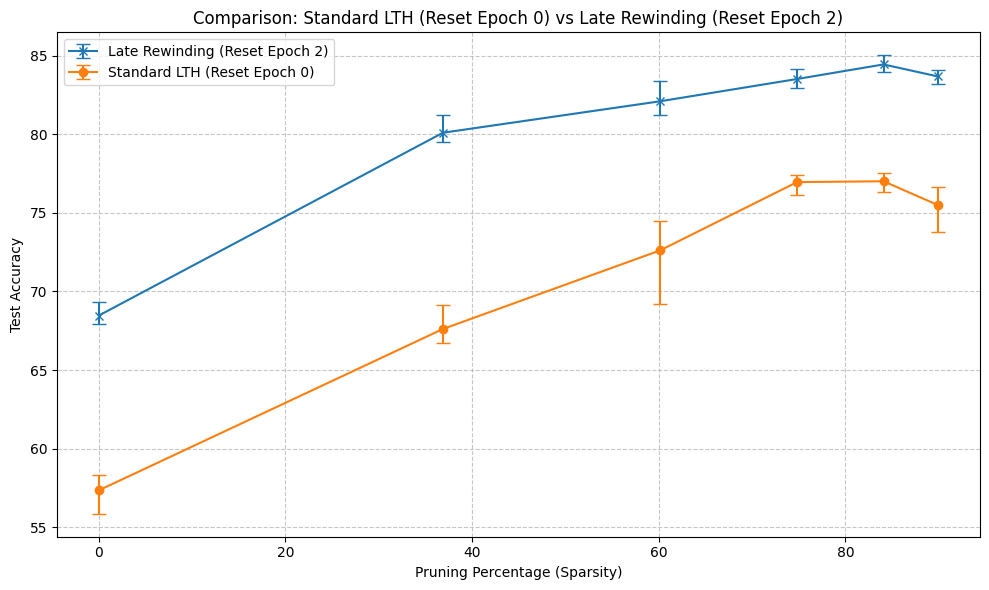

In [3]:
# plot
comparing_methods_plotting(
    df_std, 
    df_rewind, 
    "Standard LTH (Reset Epoch 0)", 
    f"Late Rewinding (Reset Epoch {REWIND_EPOCH})",dataset_name="CIFAR-10"
)

## Extension: "Strong Lottery Ticket Hypothesis" (Pruning without Training)

Based on the theoretical proofs by Da Cunha et al. (2022), the Strong Lottery Ticket Hypothesis asserts that sufficiently overparameterized networks contain subnetworks that perform well without any weight training. This extension applies when investigating the intrinsic representational power of random initializations, where the goal is to optimize only the connectivity (the binary mask) while keeping the random weights frozen. Unlike the standard LTH which requires expensive retraining steps, this method demonstrates that finding the correct topological structure within random noise is sufficient for high performance. This effectively shifts the focus from optimizing parameter values to optimizing network architecture (pruning) as the primary learning mechanism.

In [4]:
# parameters for Strong LTH experiment
target_sparsities = [0, 20, 50, 70, 80, 85, 90] 
EPOCHS = 20  
LR = 0.1  

results = []

# plot for different sparsities
for sparsity in tqdm(target_sparsities, desc="Testing Sparsities"):
    
    acc = run_strong_lth_experiment(
        target_prune_percent=sparsity, 
        epochs=EPOCHS, 
        lr=LR
    )
    
    results.append({
        "Sparsity (%)": sparsity,
        "Test Accuracy (%)": acc
    })


df_results = pd.DataFrame(results)
print(" figures:")
print(df_results)

Testing Sparsities:   0%|          | 0/7 [00:00<?, ?it/s]


 Lancement Strong LTH (Edge-Popup) | Cible Sparsité: 0%
-> Training mask scores...


Testing Sparsities:  14%|█▍        | 1/7 [10:19<1:01:57, 619.55s/it]

Résultat Strong LTH : 19.82% d'accuracy avec 0% de poids supprimés (et poids figés!).

 Lancement Strong LTH (Edge-Popup) | Cible Sparsité: 20%
-> Training mask scores...


Testing Sparsities:  29%|██▊       | 2/7 [20:35<51:26, 617.38s/it]  

...

Résultat Strong LTH : 48.15% d'accuracy avec 80% de poids supprimés (et poids figés!).

 Lancement Strong LTH (Edge-Popup) | Cible Sparsité: 85%
-> Training mask scores...


Testing Sparsities:  86%|████████▌ | 6/7 [1:01:39<10:15, 615.25s/it]

Résultat Strong LTH : 45.69% d'accuracy avec 85% de poids supprimés (et poids figés!).

 Lancement Strong LTH (Edge-Popup) | Cible Sparsité: 90%
-> Training mask scores...


Testing Sparsities: 100%|██████████| 7/7 [1:11:59<00:00, 617.06s/it]

Résultat Strong LTH : 39.37% d'accuracy avec 90% de poids supprimés (et poids figés!).
 figures:
   Sparsity (%)  Test Accuracy (%)
0             0              19.82
1            20              35.95
2            50              55.87
3            70              51.09
4            80              48.15
5            85              45.69
6            90              39.37


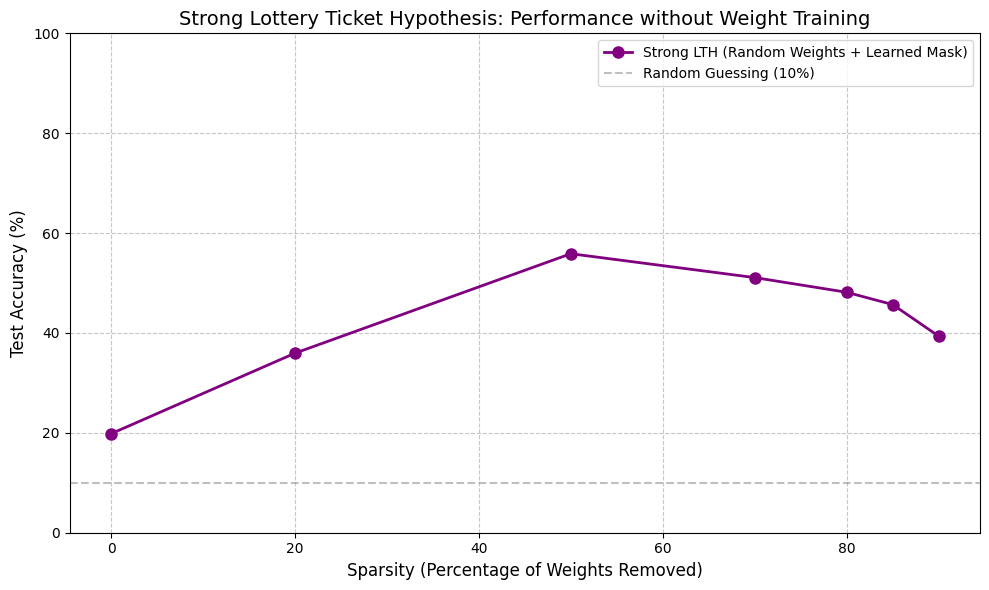

In [5]:
#plot
plt.figure(figsize=(10, 6))
plt.plot(df_results["Sparsity (%)"], df_results["Test Accuracy (%)"], 
         marker='o', linestyle='-', linewidth=2, markersize=8, color='purple', label="Strong LTH (Random Weights + Learned Mask)")
plt.axhline(y=10, color='gray', linestyle='--', alpha=0.5, label="Random Guessing (10%)")

plt.title("Strong Lottery Ticket Hypothesis: Performance without Weight Training", fontsize=14)
plt.xlabel("Sparsity (Percentage of Weights Removed)", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(0, 100) 

# download for report
plt.tight_layout()
plt.savefig("Strong_LTH_Results.png", dpi=300)
plt.show()